## Definitions

In [ ]:
#%matplotlib inline
import os
import numpy as np
import pickle
import matplotlib.pyplot as plt

from keras.utils import to_categorical
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from keras.optimizers import Adadelta, Adam, SGD
from keras.layers import Input, Conv2D, Dense, MaxPooling2D, Dropout, Flatten, AveragePooling2D, Conv2DTranspose, UpSampling2D
from keras.models import Sequential
from keras.losses import categorical_crossentropy


## Load and format data

Number of classes: 10
Example of handwritten digit with correlated noise: 



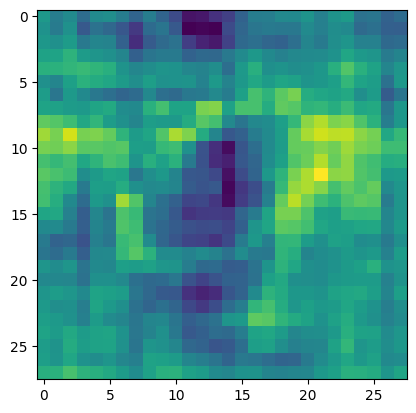

Class: 9

Shape of x_train: (60000, 28, 28, 1)
Shape of y_train: (60000, 10)


In [37]:
data = np.load('./MNIST_CorrNoise.npz')
x_train = data['x_train']
y_train = data['y_train']

num_cls = len(np.unique(y_train))
print('Number of classes: ' + str(num_cls))

print('Example of handwritten digit with correlated noise: \n')

k = 3000
plt.imshow(np.squeeze(x_train[k,:,:]))
plt.show()
print('Class: '+str(y_train[k])+'\n')

# RESHAPE and standarize
x_train = np.expand_dims(x_train/255,axis=3)

# convert class vectors to binary class matrices
y_train = to_categorical(y_train, num_cls)

print('Shape of x_train: '+str(x_train.shape))
print('Shape of y_train: '+str(y_train.shape))

## Training

In [38]:
model_name='CNN' # To compare models, you can give them different names

pweight='./weights/weights_' + model_name  + '.keras'

if not os.path.exists('./weights'):
  os.mkdir('./weights')

## EXPLORE VALUES AND FIND A GOOD SET
b_size = 128 # batch size
val_split = 0.2 # percentage of samples used for validation (e.g. 0.5)
ep = 45 # number of epochs

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_16 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_18 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_19 (Conv2D)              │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 467,818 (1.78 MB)

 Trainable params: 467,818 (1.78 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.3020 - loss: 1.9102
Epoch 1: val_loss improved from None to 0.50979, saving model to ./weights/weights_CNN.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 25s 64ms/step - accuracy: 0.4827 - loss: 1.4654 - val_accuracy: 0.8376 - val_loss: 0.5098 - learning_rate: 0.0010
Epoch 2/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.7516 - loss: 0.7552
Epoch 2: val_loss improved from 0.50979 to 0.37091, saving model to ./weights/weights_CNN.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 30s 81ms/step - accuracy: 0.7675 - loss: 0.7144 - val_accuracy: 0.8808 - val_loss: 0.3709 - learning_rate: 0.0010
Epoch 3/45
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.8083 - loss: 0.6025
Epoch 3: val_loss improved from 0.37091 to 0.30746, saving model to ./weights/weights_CNN.keras
375/375 ━━━━━━━━━━━━━━━━━━━━ 42s 84ms/step - accuracy: 0.8154 - loss: 0.5794 - val_accuracy: 0.8988 - val_loss: 0.3075 - learning_rate: 0.0010
Epoch 4/45
375/375 ━━━━━━

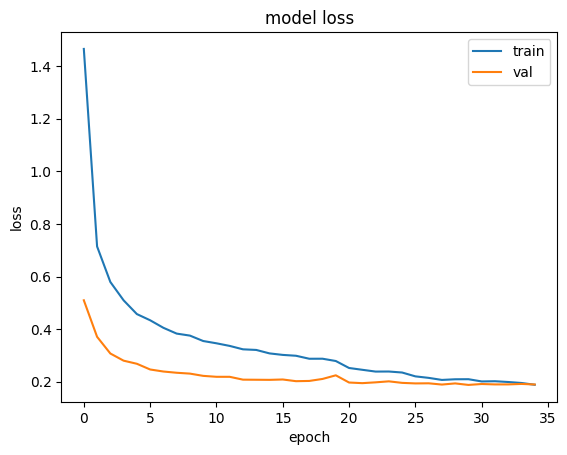

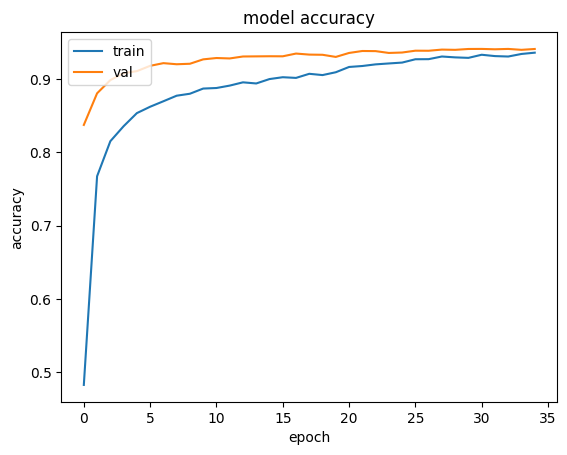


Final Training Accuracy: 0.9362
Final Validation Accuracy: 0.9413


In [39]:
input_shape = x_train.shape[1:4] #(28,28,1)
model = Sequential()

## EXPLORE LAYERS, # CHANNELS... Conv2D, Dense, MaxPooling2D, Dropout, Flatten, AveragePooling2D, Conv2DTranspose, UpSampling2D
## SEE KERAS MANUAL https://keras.io/layers/about-keras-layers/
model.add(Conv2D(32, (3,3), activation='relu', input_shape=input_shape, padding='same'))
model.add(Conv2D(32, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(Conv2D(64, (3,3), activation='relu', padding='same'))
model.add(MaxPooling2D((2,2)))
model.add(Dropout(0.3))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.6))
model.add(Dense(num_cls, activation='softmax')) # This is a necessary output layer, however, you can add more dense layers before with different activation functions

model.compile(loss=categorical_crossentropy,
              optimizer=Adam(), # explore other optimizers: Adam, SGD
              metrics=['accuracy'])

model.summary()

checkpointer = ModelCheckpoint(filepath=pweight, verbose=1, save_best_only=True)
reduce_learningrate_on_plateau = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
callbacks_list = [checkpointer,reduce_learningrate_on_plateau,early_stopping] # explore adding other callbacks such as ReduceLROnPlateau, EarlyStopping

history=model.fit(x_train, y_train,
                        epochs=ep,
                        batch_size=b_size,
                        verbose=1,
                        shuffle=True,
                        validation_split = val_split,
                        callbacks=callbacks_list)

print('CNN weights saved in ' + pweight)

# Plot loss vs epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

# Plot accuracy vs epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

print(f'\nFinal Training Accuracy: {history.history["accuracy"][-1]:.4f}')
print(f'Final Validation Accuracy: {history.history["val_accuracy"][-1]:.4f}')

## Make predictions in test set

In [40]:
from keras.models import load_model

## LOAD DATA
data = np.load('./MNIST_CorrNoise.npz')

x_test = data['x_test']
y_test = data['y_test']

num_cls = len(np.unique(y_test))
print('Number of classes: ' + str(num_cls))

# RESHAPE and standarize
x_test = np.expand_dims(x_test/255,axis=3)

print('Shape of x_test: '+str(x_test.shape)+'\n')

## Define model parameters
model_name='CNN' # To compare models, you can give them different names
pweight='./weights/weights_' + model_name  + '.keras'

model = load_model(pweight)

y_pred_prob = model.predict(x_test)
y_pred = np.argmax(y_pred_prob, axis=1)

Acc_pred = sum(y_pred == y_test)/len(y_test)

print('Accuracy in test set is: '+str(Acc_pred))
print('Accuracy in test set is: {:.2%}'.format(Acc_pred))

Number of classes: 10
Shape of x_test: (10000, 28, 28, 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Accuracy in test set is: 0.9375
Accuracy in test set is: 93.75%


In [41]:
train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss   = history.history['val_loss']

final_train_acc = train_acc[-1]
final_val_acc   = val_acc[-1]
gap = final_train_acc - final_val_acc

print(f"Final Training Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")
print(f"Generalization Gap: {gap:.4f}")

if gap > 0.05 and final_val_acc < 0.95:
    print("⚠️ Model may be OVERFITTING (training >> validation). Try more regularization or data augmentation.")
elif gap < 0.02 and final_train_acc < 0.85:
    print("⚠️ Model may be UNDERFITTING (both accuracies low). Try deeper network or more epochs.")
else:
    print("✅ Model seems well-balanced between bias and variance.")

Final Training Accuracy: 0.9362
Final Validation Accuracy: 0.9413
Generalization Gap: -0.0050
✅ Model seems well-balanced between bias and variance.


In [42]:
def analyze_overfitting(history):
    """Quantitative analysis of overfitting"""
    final_train_loss = history.history['loss'][-1]
    final_val_loss = history.history['val_loss'][-1]
    final_train_acc = history.history['accuracy'][-1]
    final_val_acc = history.history['val_accuracy'][-1]
    
    loss_gap = final_train_loss - final_val_loss
    acc_gap = final_val_acc - final_train_acc
    
    print("=== Overfitting Analysis ===")
    print(f"Final Training Loss: {final_train_loss:.4f}")
    print(f"Final Validation Loss: {final_val_loss:.4f}")
    print(f"Loss Gap: {loss_gap:.4f}")
    print(f"Accuracy Gap: {acc_gap:.4f}")
    
    if loss_gap > 0.1 or acc_gap < -0.05:
        print("❌ Significant overfitting detected!")
        return True
    elif abs(loss_gap) < 0.02 and abs(acc_gap) < 0.01:
        print("✅ Good generalization!")
        return False
    else:
        print("⚠️  Mild overfitting, consider adjustments")
        return None

is_overfitting = analyze_overfitting(history)

=== Overfitting Analysis ===
Final Training Loss: 0.1886
Final Validation Loss: 0.1897
Loss Gap: -0.0011
Accuracy Gap: 0.0050
✅ Good generalization!


In [43]:
## OVERFITTING/UNDERFITTING ANALYSIS

print("="*70)
print("MODEL PERFORMANCE ANALYSIS")
print("="*70)

# Get final accuracies from training history
final_train_acc = history.history['accuracy'][-1]
final_val_acc = history.history['val_accuracy'][-1]
final_train_loss = history.history['loss'][-1]
final_val_loss = history.history['val_loss'][-1]

# Calculate the gap between training and validation
acc_gap = final_train_acc - final_val_acc
loss_gap = final_val_loss - final_train_loss

print(f"\n📊 TRAINING METRICS:")
print(f"   Training Accuracy:   {final_train_acc:.4f} ({final_train_acc*100:.2f}%)")
print(f"   Validation Accuracy: {final_val_acc:.4f} ({final_val_acc*100:.2f}%)")
print(f"   Accuracy Gap:        {acc_gap:.4f} ({acc_gap*100:.2f}%)")
print(f"\n   Training Loss:       {final_train_loss:.4f}")
print(f"   Validation Loss:     {final_val_loss:.4f}")
print(f"   Loss Gap:            {loss_gap:.4f}")

# Add test accuracy if available
if 'Acc_pred' in locals():
    print(f"\n   Test Accuracy:       {Acc_pred:.4f} ({Acc_pred*100:.2f}%)")
    test_val_gap = final_val_acc - Acc_pred
    print(f"   Val-Test Gap:        {test_val_gap:.4f} ({test_val_gap*100:.2f}%)")

print("\n" + "="*70)
print("DIAGNOSIS")
print("="*70)

# Determine if model is overfitting, underfitting, or well-fitted
diagnosis = []
severity = "GOOD"

# Check for overfitting
if acc_gap > 0.15:  # More than 15% gap
    diagnosis.append("🔴 SEVERE OVERFITTING")
    severity = "BAD"
    print("\n⚠️  SEVERE OVERFITTING DETECTED!")
    print("   The model memorizes training data but fails to generalize.")
elif acc_gap > 0.08:  # 8-15% gap
    diagnosis.append("🟡 MODERATE OVERFITTING")
    severity = "MODERATE"
    print("\n⚠️  MODERATE OVERFITTING DETECTED")
    print("   The model shows signs of memorizing training data.")
elif acc_gap > 0.03:  # 3-8% gap
    diagnosis.append("🟢 SLIGHT OVERFITTING (Acceptable)")
    print("\n✓  SLIGHT OVERFITTING (Within acceptable range)")
    print("   Small gap is normal and acceptable.")
else:
    diagnosis.append("🟢 NO SIGNIFICANT OVERFITTING")
    print("\n✓  NO SIGNIFICANT OVERFITTING")
    print("   Training and validation performance are well-balanced.")

# Check for underfitting
if final_val_acc < 0.85:  # Less than 85% validation accuracy
    diagnosis.append("🔴 UNDERFITTING")
    severity = "BAD"
    print("\n⚠️  UNDERFITTING DETECTED!")
    print("   The model is too simple to capture patterns in the data.")
elif final_val_acc < 0.92:  # 85-92% validation accuracy
    diagnosis.append("🟡 POSSIBLE UNDERFITTING")
    if severity != "BAD":
        severity = "MODERATE"
    print("\n⚠️  POSSIBLE UNDERFITTING")
    print("   The model could potentially learn more from the data.")
else:
    print("   ✓  Model has learned the data well.")

# Check validation loss trend
val_loss_trend = np.diff(history.history['val_loss'][-5:])  # Last 5 epochs
if np.mean(val_loss_trend) > 0:
    print("\n⚠️  Validation loss is increasing - early signs of overfitting")
    if severity == "GOOD":
        severity = "MODERATE"

print("\n" + "="*70)
print("RECOMMENDATIONS")
print("="*70)

if "SEVERE OVERFITTING" in diagnosis[0]:
    print("\n🔧 TO REDUCE OVERFITTING:")
    print("   1. ✓ Increase dropout rates (currently 0.25-0.5)")
    print("   2. ✓ Add more dropout layers")
    print("   3. ✓ Reduce model complexity (fewer layers or filters)")
    print("   4. ✓ Increase training data or use data augmentation")
    print("   5. ✓ Add L2 regularization to Dense/Conv layers")
    print("   6. ✓ Reduce number of epochs or use early stopping")
    
elif "MODERATE OVERFITTING" in diagnosis[0]:
    print("\n🔧 TO REDUCE OVERFITTING:")
    print("   1. ✓ Slightly increase dropout rates")
    print("   2. ✓ Use data augmentation")
    print("   3. ✓ Ensure early stopping is working properly")
    
elif "UNDERFITTING" in str(diagnosis):
    print("\n🔧 TO REDUCE UNDERFITTING:")
    print("   1. ✓ Increase model complexity (more layers or filters)")
    print("   2. ✓ Train for more epochs")
    print("   3. ✓ Reduce dropout rates")
    print("   4. ✓ Use a more powerful optimizer or tune learning rate")
    print("   5. ✓ Check if data preprocessing is correct")
    print("   6. ✓ Add batch normalization layers")

else:
    print("\n✅ MODEL IS WELL-FITTED!")
    print("   Your model shows good balance between bias and variance.")
    print("   Continue with this architecture and hyperparameters.")

# Visual analysis
print("\n" + "="*70)
print("VISUAL ANALYSIS")
print("="*70)

# Summary score
print(f"\n{'='*70}")
print(f"OVERALL MODEL HEALTH: {severity}")
print(f"{'='*70}")

if severity == "GOOD":
    print("🎉 Excellent! Your model is performing well.")
elif severity == "MODERATE":
    print("⚠️  Your model works but could be improved.")
else:
    print("❌ Your model needs significant improvements.")

MODEL PERFORMANCE ANALYSIS

📊 TRAINING METRICS:
   Training Accuracy:   0.9362 (93.62%)
   Validation Accuracy: 0.9413 (94.13%)
   Accuracy Gap:        -0.0050 (-0.50%)

   Training Loss:       0.1886
   Validation Loss:     0.1897
   Loss Gap:            0.0011

   Test Accuracy:       0.9375 (93.75%)
   Val-Test Gap:        0.0038 (0.38%)

DIAGNOSIS

✓  NO SIGNIFICANT OVERFITTING
   Training and validation performance are well-balanced.
   ✓  Model has learned the data well.

RECOMMENDATIONS

✅ MODEL IS WELL-FITTED!
   Your model shows good balance between bias and variance.
   Continue with this architecture and hyperparameters.

VISUAL ANALYSIS

OVERALL MODEL HEALTH: GOOD
🎉 Excellent! Your model is performing well.
